<a href="https://colab.research.google.com/github/rramonmacedo/INTELIG-NCIA-ARTIFICIAL_atv/blob/main/Teste_1_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Teste 1 - Inteligência Artificial: Análise de Crédito
**Objetivo:** Construir um modelo de regressão para estimar o valor do empréstimo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Carregar os dados

In [ ]:
df = pd.read_csv('base_credito.csv')
display(df.head())

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


In [ ]:
df = pd.read_csv('base_credito.csv')
display(df.head())

,idade,renda_mensal,score_credito,historico_pagamentos,valor_emprestimo
0,47,11522.48,634,76.73,35229.74
1,40,13157.86,589,90.83,44177.99
2,38,7296.76,721,77.94,33868.30
3,42,11193.87,710,94.09,52289.28
4,43,12798.60,576,73.83,38663.54


### Verificação de Valores Nulos

In [ ]:
print('Valores nulos por coluna:')
display(df.isnull().sum())

Valores nulos por coluna:


,0
idade,0
renda_mensal,0
score_credito,0
historico_pagamentos,0
valor_emprestimo,0


## 2. Conhecer os dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 50000 non-null  int64  
 1   renda_mensal          50000 non-null  float64
 2   score_credito         50000 non-null  int64  
 3   historico_pagamentos  50000 non-null  float64
 4   valor_emprestimo      50000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 1.9 MB


## 3. Analisar os dados

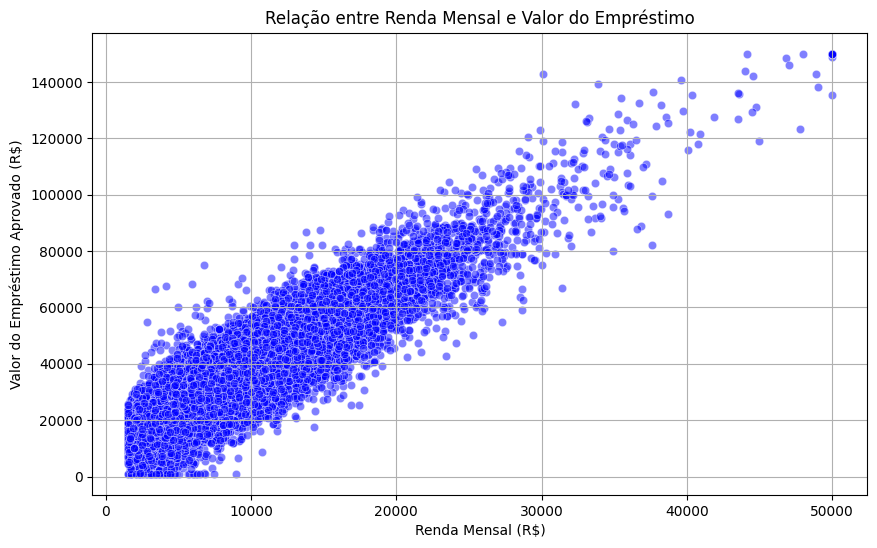

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='renda_mensal', y='valor_emprestimo', alpha=0.5, color='blue')
plt.title('Relação entre Renda Mensal e Valor do Empréstimo')
plt.xlabel('Renda Mensal (R$)')
plt.ylabel('Valor do Empréstimo Aprovado (R$)')
plt.grid(True)
plt.show()

## 4. Preparar os dados

In [ ]:
X = df.drop('valor_emprestimo', axis=1)
y = df['valor_emprestimo']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Tamanho do conjunto de treinamento: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Tamanho do conjunto de treinamento: 40000 amostras
Tamanho do conjunto de teste: 10000 amostras


## 5. Treinar o modelo

In [ ]:
modelo_regressao = LinearRegression()
modelo_regressao.fit(X_train, y_train)
y_pred = modelo_regressao.predict(X_test)

## 6. Avaliar o modelo

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Erro Médio Absoluto (MAE): R$ {mae:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.4f}")

Erro Médio Absoluto (MAE): R$ 2985.94
Coeficiente de Determinação (R²): 0.9223


## 7. Comparar valores reais e previstos

In [ ]:
df_comparacao = pd.DataFrame({
    'Valor Real (R$)': y_test.values,
    'Valor Previsto (R$)': y_pred
})
df_comparacao['Diferença / Erro (R$)'] = abs(df_comparacao['Valor Real (R$)'] - df_comparacao['Valor Previsto (R$)'])
display(df_comparacao.head(10).round(2))

,Valor Real (R$),Valor Previsto (R$),Diferença / Erro (R$)
0,22268.46,14806.34,7462.12
1,27457.59,29512.49,2054.90
2,25451.04,25840.74,389.70
3,23890.67,21077.52,2813.15
4,27754.95,27919.31,164.36
5,12544.92,14530.91,1985.99
6,28759.01,27385.97,1373.04
7,46454.49,41011.61,5442.88
8,43199.01,36525.09,6673.92
9,34051.39,35786.96,1735.57


## 8. Fazer uma previsão

In [ ]:
novo_cliente = pd.DataFrame({
    'idade': [35],
    'renda_mensal': [8500.00],
    'score_credito': [750],
    'historico_pagamentos': [95.0]
})
valor_aprovado = modelo_regressao.predict(novo_cliente)
print(f"Para um cliente de 35 anos, renda de R$ 8500, score 750 e histórico de 95%,")
print(f"O modelo estima um limite de empréstimo de: R$ {valor_aprovado[0]:.2f}")

Para um cliente de 35 anos, renda de R$ 8500, score 750 e histórico de 95%,
O modelo estima um limite de empréstimo de: R$ 41580.95


## 9. Conclusão
Conclusão

O modelo entregou resultados muito bons para o que foi pedido.A inteligência artificial consegue explicar bem o valor do empréstimo só de olhar a renda e o score do cliente.

Sobre as limitações do modelo: notei que pode ser bem sensível se entrarem uns dados muito fora do padrão. Outra coisa é que se a empresa tiver umas regras de crédito cheias de detalhes e exceções, o modelo não vai conseguir capturar isso direito.
